imports

In [59]:
import pandas as pd
import numpy as np
from helpers import dep2pyodbc
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime, timedelta

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix


DWH connection

In [60]:
# TODO: change to use dep2connect
channel = dep2pyodbc.dep2connection("CRH_DWH")

# channel = pyodbc.connect("DRIVER={ODBC Driver 17 for SQL Server};SERVER=LAPTOPLISA;DATABASE=CRH_DWH;UID=LaptopLisa/verho;Trusted_Connection=yes")
cursor = channel.cursor()

pyodbc using windows


# Getting and cleaning data

In [61]:
query = """
        SELECT FCAQuestionKey, fq.FCATestKey, ItemID, TimeSpent AS TimeSpentQuestion, dts.tekst AS TestStartTime,
		dtf.tekst AS TestFinishTime, ft.CandidateKey, Gender, ChosenGender, ChosenLanguage, Qualification
        FROM FactQuestionFCA fq
                JOIN FactTestFCA ft ON fq.FCATestKey=ft.FCATestKey
                JOIN DimCandidate dc ON ft.CandidateKey=dc.CandidateKey
	        JOIN DimTime dts ON ft.TestStartTimeKey=dts.TimeKey
		JOIN DimTime dtf ON ft.TestFinishTimeKey=dtf.TimeKey
        """
df_fca = pd.read_sql(query, channel)

df_fca.head()

C:\Users\verho\AppData\Local\Temp\ipykernel_65484\1638610138.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fca = pd.read_sql(query, channel)


,FCAQuestionKey,FCATestKey,ItemID,TimeSpentQuestion,TestStartTime,TestFinishTime,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification
0,1,1,222,11.0,9:31:54,9:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
1,2,1,223,3.0,9:31:54,9:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
2,3,1,226,13.0,9:31:54,9:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
3,4,1,229,100.0,9:31:54,9:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
4,5,1,238,2.0,9:31:54,9:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown


In [62]:
df_fca["TimeSpentQuestion"] = df_fca["TimeSpentQuestion"].astype(int)
df_fca["TestStartTime"] = pd.to_datetime(df_fca["TestStartTime"], format="%H:%M:%S").dt.time
df_fca["TestFinishTime"] = pd.to_datetime(df_fca["TestFinishTime"], format="%H:%M:%S").dt.time

df_fca.head()


,FCAQuestionKey,FCATestKey,ItemID,TimeSpentQuestion,TestStartTime,TestFinishTime,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification
0,1,1,222,11,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
1,2,1,223,3,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
2,3,1,226,13,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
3,4,1,229,100,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown
4,5,1,238,2,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown


In [63]:
df_fca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035705 entries, 0 to 3035704
Data columns (total 11 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   FCAQuestionKey     int64 
 1   FCATestKey         int64 
 2   ItemID             int64 
 3   TimeSpentQuestion  int32 
 4   TestStartTime      object
 5   TestFinishTime     object
 6   CandidateKey       int64 
 7   Gender             object
 8   ChosenGender       object
 9   ChosenLanguage     object
 10  Qualification      object
dtypes: int32(1), int64(4), object(6)
memory usage: 243.2+ MB


In [64]:
df_fca.describe()

,FCAQuestionKey,FCATestKey,ItemID,TimeSpentQuestion,CandidateKey
count,3.035705e+06,3.035705e+06,3.035705e+06,3.035705e+06,3.035705e+06
mean,1.517853e+06,7.947524e+04,3.049683e+02,1.802217e+02,4.075367e+07
std,8.763327e+05,4.593931e+04,9.079508e+01,4.684064e+02,5.938629e+06
min,1.000000e+00,1.000000e+00,1.170000e+02,0.000000e+00,1.140000e+02
25%,7.589270e+05,3.977300e+04,2.290000e+02,5.700000e+01,3.738281e+07
50%,1.517853e+06,7.924000e+04,2.380000e+02,1.000000e+02,4.126908e+07
75%,2.276779e+06,1.187020e+05,4.130000e+02,1.760000e+02,4.452836e+07
max,3.035705e+06,1.600670e+05,4.470000e+02,1.638300e+04,5.083218e+07


In [65]:
# df_fca["TimeSpentTest"] = df_fca.apply(lambda row: datetime.combine(datetime.today(), row['TestFinishTime']) - datetime.combine(datetime.today(), row['TestStartTime']), axis=1)
df_fca["TimeSpentTest"] = df_fca.apply(lambda row: 
    (datetime.combine(datetime.today(), row['TestFinishTime']) + timedelta(days=1) if row['TestFinishTime'] < row['TestStartTime'] else datetime.combine(datetime.today(), row['TestFinishTime'])) 
    - datetime.combine(datetime.today(), row['TestStartTime']), axis=1)
df_fca["TimeSpentTest"] = df_fca["TimeSpentTest"].dt.total_seconds()
df_fca["TimeSpentTest"] = df_fca["TimeSpentTest"].astype(int)

df_fca.head()

,FCAQuestionKey,FCATestKey,ItemID,TimeSpentQuestion,TestStartTime,TestFinishTime,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification,TimeSpentTest
0,1,1,222,11,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,18
1,2,1,223,3,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,18
2,3,1,226,13,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,18
3,4,1,229,100,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,18
4,5,1,238,2,09:31:54,09:32:12,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,18


In [66]:
df_fca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035705 entries, 0 to 3035704
Data columns (total 12 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   FCAQuestionKey     int64 
 1   FCATestKey         int64 
 2   ItemID             int64 
 3   TimeSpentQuestion  int32 
 4   TestStartTime      object
 5   TestFinishTime     object
 6   CandidateKey       int64 
 7   Gender             object
 8   ChosenGender       object
 9   ChosenLanguage     object
 10  Qualification      object
 11  TimeSpentTest      int32 
dtypes: int32(2), int64(4), object(6)
memory usage: 254.8+ MB


In [67]:
# df_fca.drop(columns=["TestStartTime", "TestFinishTime"], inplace=True)
df_fca = df_fca[["FCATestKey", "FCAQuestionKey", "ItemID", "TimeSpentTest", "TimeSpentQuestion", "CandidateKey", "Gender", "ChosenGender", "ChosenLanguage", "Qualification", "TestStartTime", "TestFinishTime"]]

df_fca.head()

,FCATestKey,FCAQuestionKey,ItemID,TimeSpentTest,TimeSpentQuestion,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification,TestStartTime,TestFinishTime
0,1,1,222,18,11,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12
1,1,2,223,18,3,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12
2,1,3,226,18,13,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12
3,1,4,229,18,100,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12
4,1,5,238,18,2,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12


In [68]:
df_fca.describe()

,FCATestKey,FCAQuestionKey,ItemID,TimeSpentTest,TimeSpentQuestion,CandidateKey
count,3.035705e+06,3.035705e+06,3.035705e+06,3.035705e+06,3.035705e+06,3.035705e+06
mean,7.947524e+04,1.517853e+06,3.049683e+02,2.411967e+03,1.802217e+02,4.075367e+07
std,4.593931e+04,8.763327e+05,9.079508e+01,2.846481e+03,4.684064e+02,5.938629e+06
min,1.000000e+00,1.000000e+00,1.170000e+02,0.000000e+00,0.000000e+00,1.140000e+02
25%,3.977300e+04,7.589270e+05,2.290000e+02,1.633000e+03,5.700000e+01,3.738281e+07
50%,7.924000e+04,1.517853e+06,2.380000e+02,2.251000e+03,1.000000e+02,4.126908e+07
75%,1.187020e+05,2.276779e+06,4.130000e+02,3.027000e+03,1.760000e+02,4.452836e+07
max,1.600670e+05,3.035705e+06,4.470000e+02,8.637400e+04,1.638300e+04,5.083218e+07


## OneHotEncoding

In [69]:
encoder = OneHotEncoder(sparse_output=False)

fca_cat_encoded = encoder.fit_transform(df_fca[["Gender", "ChosenGender", "ChosenLanguage", "Qualification"]])

fca_cat_encoded

array([[1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]])

In [70]:
df_fca_cat = pd.DataFrame(fca_cat_encoded, columns=encoder.get_feature_names_out(), dtype=int)

df_fca_cat.head()

,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,ChosenGender_Gender_Female,ChosenGender_Gender_Male,ChosenGender_Gender_Other,ChosenGender_Gender_Unknown,ChosenGender_None,ChosenLanguage_63B7DCBF-919E-49A6-8BF4-7CD9042C4C44,ChosenLanguage_65CAFEA9-CF49-43ED-99AA-83AFE0539978,...,Qualification_,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
0,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,1,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [71]:
df_fca_encoded = pd.concat([df_fca[["FCATestKey", "FCAQuestionKey", "ItemID", "TimeSpentTest", "TimeSpentQuestion", "CandidateKey"]], df_fca_cat], axis=1)

df_fca_encoded.head()

,FCATestKey,FCAQuestionKey,ItemID,TimeSpentTest,TimeSpentQuestion,CandidateKey,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,ChosenGender_Gender_Female,...,Qualification_,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational
0,1,1,222,18,11,544,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,1,2,223,18,3,544,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,1,3,226,18,13,544,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,1,4,229,18,100,544,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,1,5,238,18,2,544,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0


# Visualise data

## Overview plots

array([[<Axes: xlabel='FCATestKey', ylabel='FCATestKey'>,
        <Axes: xlabel='FCAQuestionKey', ylabel='FCATestKey'>,
        <Axes: xlabel='ItemID', ylabel='FCATestKey'>,
        <Axes: xlabel='TimeSpentTest', ylabel='FCATestKey'>,
        <Axes: xlabel='TimeSpentQuestion', ylabel='FCATestKey'>,
        <Axes: xlabel='CandidateKey', ylabel='FCATestKey'>],
       [<Axes: xlabel='FCATestKey', ylabel='FCAQuestionKey'>,
        <Axes: xlabel='FCAQuestionKey', ylabel='FCAQuestionKey'>,
        <Axes: xlabel='ItemID', ylabel='FCAQuestionKey'>,
        <Axes: xlabel='TimeSpentTest', ylabel='FCAQuestionKey'>,
        <Axes: xlabel='TimeSpentQuestion', ylabel='FCAQuestionKey'>,
        <Axes: xlabel='CandidateKey', ylabel='FCAQuestionKey'>],
       [<Axes: xlabel='FCATestKey', ylabel='ItemID'>,
        <Axes: xlabel='FCAQuestionKey', ylabel='ItemID'>,
        <Axes: xlabel='ItemID', ylabel='ItemID'>,
        <Axes: xlabel='TimeSpentTest', ylabel='ItemID'>,
        <Axes: xlabel='TimeSpentQue

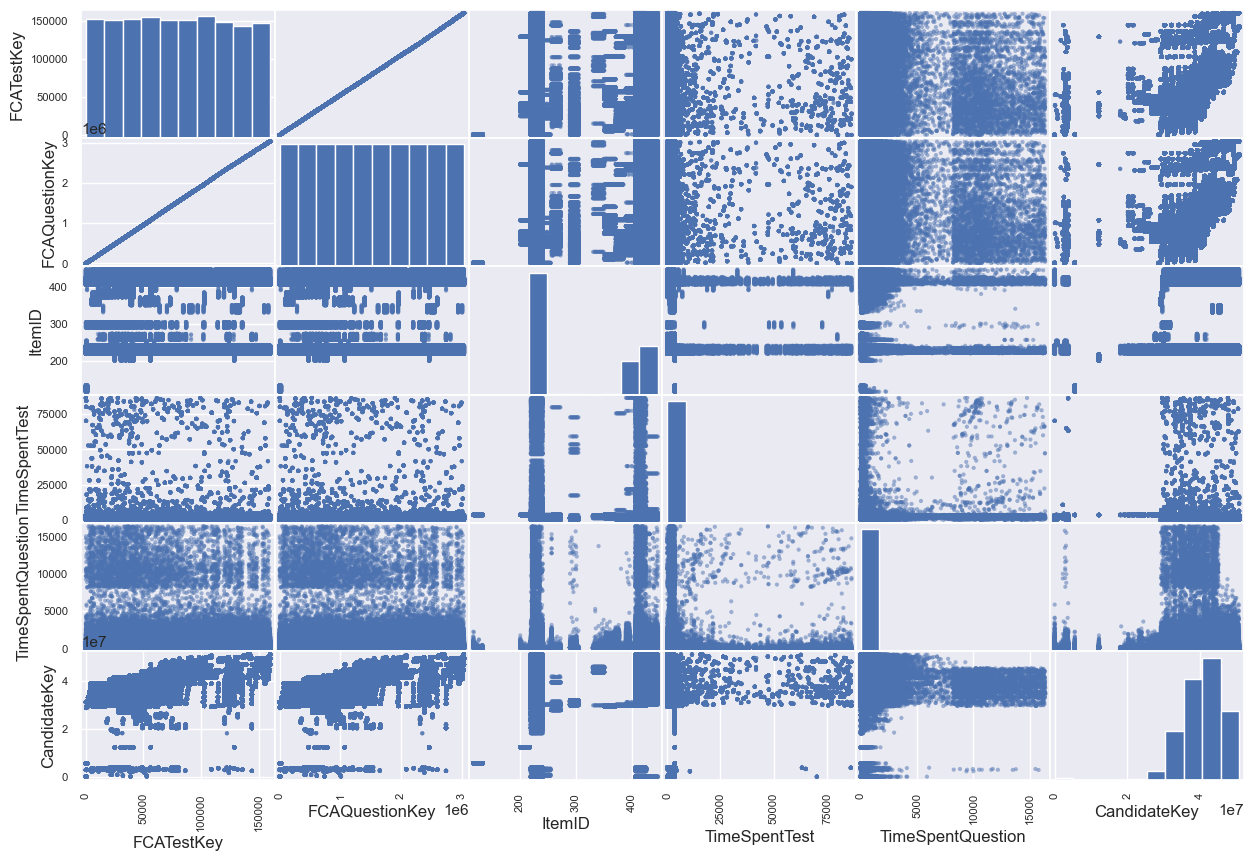

In [72]:
attributes = ["FCATestKey", "FCAQuestionKey", "ItemID", "TimeSpentTest", "TimeSpentQuestion", "CandidateKey", "Gender", "ChosenGender", "ChosenLanguage", "Qualification"]

scatter_matrix(df_fca[attributes], figsize=(15,10))

## Time spent questions

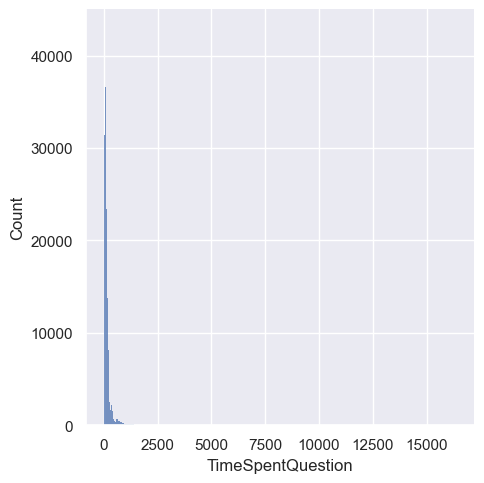

In [73]:
sns.set_theme()

sns.displot(df_fca, x='TimeSpentQuestion')

<Axes: xlabel='TimeSpentQuestion', ylabel='Percent'>

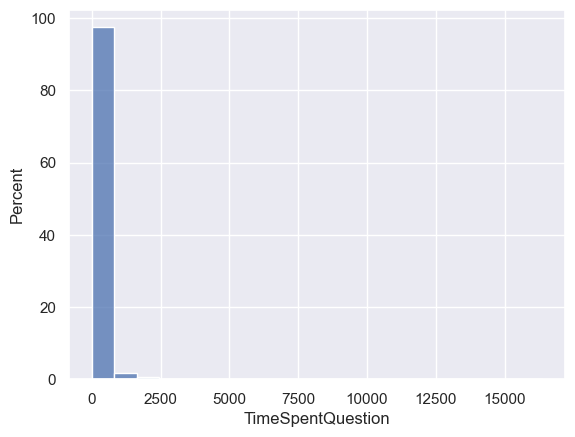

In [74]:
sns.histplot(df_fca, x="TimeSpentQuestion", bins=20, stat="percent")

It's clear that there are some outliers in TimeSpentQuestion

<Axes: xlabel='TimeSpentQuestion', ylabel='ItemID'>

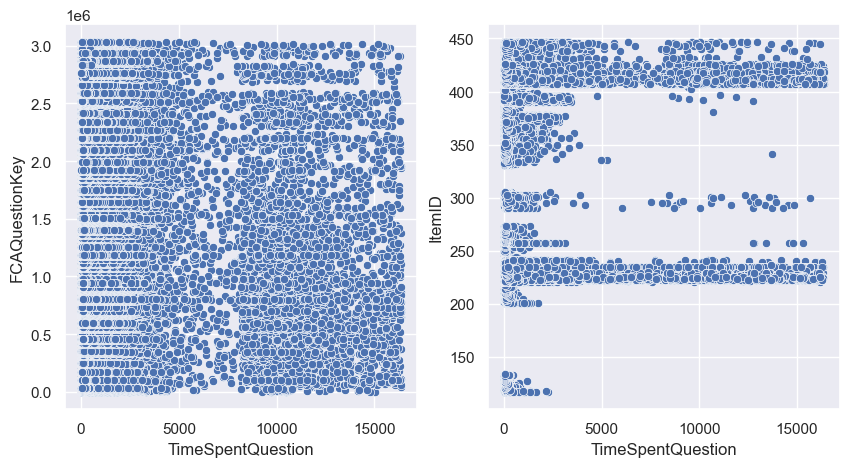

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

sns.scatterplot(df_fca, x="TimeSpentQuestion", y="FCAQuestionKey", ax=axes[0])
sns.scatterplot(df_fca, x="TimeSpentQuestion", y="ItemID", ax=axes[1])

We might have to take into consideration that we'll have to look the outliers per itemID

## Time spent tests

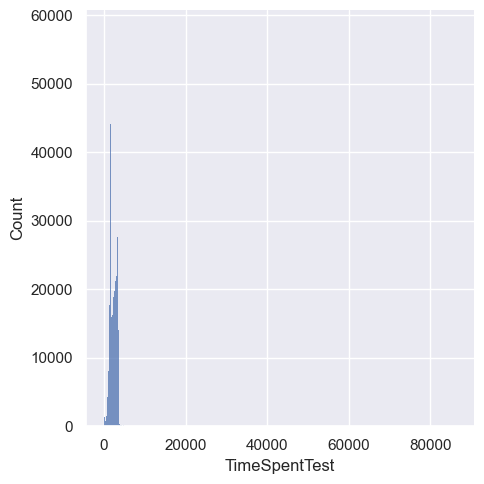

In [76]:
sns.displot(df_fca, x='TimeSpentTest')

<Axes: xlabel='TimeSpentTest', ylabel='Percent'>

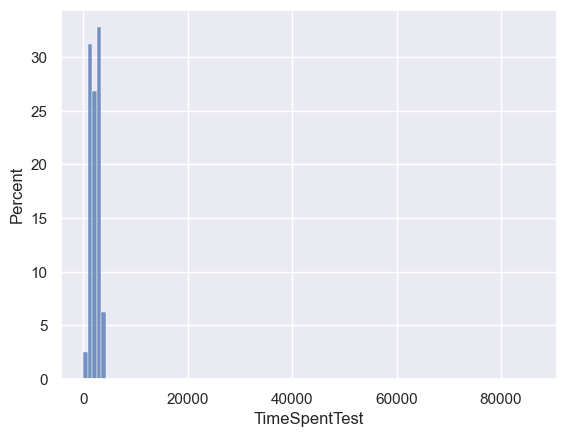

In [77]:
sns.histplot(df_fca, x="TimeSpentTest", bins=100, stat="percent")


It looks like there might also be some outliers in TimeSpentTest

<Axes: xlabel='TimeSpentTest', ylabel='CandidateKey'>

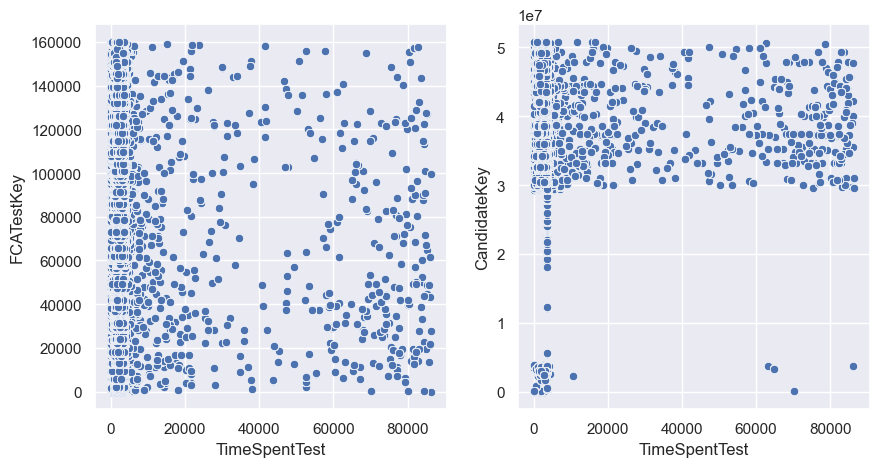

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

sns.scatterplot(df_fca, x="TimeSpentTest", y="FCATestKey", ax=axes[0])
sns.scatterplot(df_fca, x="TimeSpentTest", y="CandidateKey", ax=axes[1])

# Average values with outliers included

## Time spent question

### Average of all questions

In [79]:
meanq = df_fca["TimeSpentQuestion"].mean()
medq = df_fca["TimeSpentQuestion"].median()

print(f"The average of the time spent per question is {meanq}")
print(f"The median of the time spent per question is {medq}")

The average of the time spent per question is 180.22170467815548
The median of the time spent per question is 100.0


#### Average per ItemID

In [80]:
items = df_fca["ItemID"].unique().tolist()
items = np.sort(items)
print(items)

[117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134
 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218
 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237
 238 239 240 241 243 244 245 246 247 248 249 250 251 252 253 254 255 257
 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 290 291
 292 293 294 295 296 297 298 299 300 301 302 303 304 305 331 332 333 334
 335 336 337 338 339 340 341 342 343 344 345 346 347 348 349 350 351 352
 353 354 355 356 357 358 359 360 361 362 363 364 365 366 367 368 369 370
 371 372 373 374 375 376 377 378 379 380 381 382 383 384 385 386 387 388
 390 391 392 393 394 395 396 397 398 399 400 401 402 403 404 405 407 408
 409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 424 425 426
 427 428 429 430 431 432 433 434 435 436 437 438 439 440 441 442 443 444
 445 446 447]


In [81]:
mean_itemID = df_fca.groupby(["ItemID"])["TimeSpentQuestion"].mean()

med_itemID = df_fca.groupby(["ItemID"])["TimeSpentQuestion"].median()

df_avg_med = pd.concat([mean_itemID, med_itemID], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_avg_med

,MeanTimeSpent,MedianTimeSpent
ItemID,,
117,523.724138,441.0
118,264.603448,210.5
119,201.060345,177.5
120,113.739130,87.0
121,167.622807,144.0
122,134.973684,128.5
123,218.701754,210.0
124,144.752212,146.0
125,113.017857,104.0


### Time spent test

In [82]:
meant = df_fca["TimeSpentTest"].mean()
medt = df_fca["TimeSpentTest"].median()

print(f"The average of the time spent per test is {meant}")
print(f"The median of the time spent per test is {medt}")

The average of the time spent per test is 2411.9666950510673
The median of the time spent per test is 2251.0


## Average values without outliers

### Time spent question

#### Find the outliers

In [83]:
pd.set_option('display.max_rows', None)
print(df_fca["TimeSpentQuestion"].value_counts())

TimeSpentQuestion
48       21613
51       21496
50       21436
54       21402
47       21372
45       21320
49       21283
43       21234
46       21097
52       21096
44       21067
58       20948
53       20845
41       20841
55       20823
57       20809
42       20736
56       20699
40       20612
61       20552
60       20499
59       20445
39       20428
62       20360
63       20191
64       20009
38       19954
37       19921
65       19797
66       19792
36       19657
67       19544
68       19509
70       19158
69       19107
72       18904
71       18903
35       18870
34       18798
33       18537
74       18406
73       18312
76       18309
75       18213
32       18106
77       18064
78       17969
79       17576
81       17525
80       17467
31       17352
82       17087
83       17059
85       16741
84       16637
88       16519
86       16516
87       16506
30       16504
29       16159
90       16049
89       15983
91       15888
92       15746
93       15550
94     

Since there are a lot of different values in this column, I'll work with intervals to try and define where the outliers are in the Time spent per question.

In [84]:
print(f"Amount of different values for TimeSpentQuestion: {len(df_fca["TimeSpentQuestion"].unique())}")
print(f"Highest value TimeSpentQuestion: {df_fca["TimeSpentQuestion"].max()}")

Amount of different values for TimeSpentQuestion: 6546
Highest value TimeSpentQuestion: 16383


In [85]:
bins = list(range(0,16401, 100))

df_fca["TimeSpentQuestionInterval"] = pd.cut(df_fca["TimeSpentQuestion"], bins=bins, right=False)
df_fca.head()

,FCATestKey,FCAQuestionKey,ItemID,TimeSpentTest,TimeSpentQuestion,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification,TestStartTime,TestFinishTime,TimeSpentQuestionInterval
0,1,1,222,18,11,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)"
1,1,2,223,18,3,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)"
2,1,3,226,18,13,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)"
3,1,4,229,18,100,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[100, 200)"
4,1,5,238,18,2,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)"


In [86]:
print(df_fca["TimeSpentQuestionInterval"].value_counts())


TimeSpentQuestionInterval
[0, 100)          1513700
[100, 200)         890623
[200, 300)         293276
[300, 400)         117667
[400, 500)          59419
[500, 600)          37508
[600, 700)          25531
[700, 800)          18418
[800, 900)          13424
[900, 1000)         10291
[1000, 1100)         7973
[1100, 1200)         6395
[1200, 1300)         5226
[1300, 1400)         4393
[1400, 1500)         3849
[1500, 1600)         3497
[1600, 1700)         3033
[1700, 1800)         2700
[1800, 1900)         2405
[1900, 2000)         2059
[2000, 2100)         1768
[2100, 2200)         1527
[2200, 2300)         1228
[2300, 2400)         1024
[2400, 2500)          866
[2500, 2600)          681
[2600, 2700)          548
[2700, 2800)          408
[2800, 2900)          359
[2900, 3000)          265
[3000, 3100)          227
[3100, 3200)          223
[3200, 3300)          159
[3300, 3400)          143
[3400, 3500)          134
[3500, 3600)          108
[3800, 3900)          101
[3600, 3700)

Looking at these counts I decided to see everything that has a time spent higher than 400 as an outlier.

In [87]:
df_fca_no_outliers_question = df_fca[(df_fca["TimeSpentQuestion"] < 400)]
df_fca_no_outliers_question.head()

,FCATestKey,FCAQuestionKey,ItemID,TimeSpentTest,TimeSpentQuestion,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification,TestStartTime,TestFinishTime,TimeSpentQuestionInterval
0,1,1,222,18,11,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)"
1,1,2,223,18,3,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)"
2,1,3,226,18,13,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)"
3,1,4,229,18,100,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[100, 200)"
4,1,5,238,18,2,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)"


In [88]:
df_fca_outliers_question = df_fca[(df_fca["TimeSpentQuestion"] >= 400)]
df_fca_outliers_question.head()

,FCATestKey,FCAQuestionKey,ItemID,TimeSpentTest,TimeSpentQuestion,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification,TestStartTime,TestFinishTime,TimeSpentQuestionInterval
7,2,8,409,1993,413,854,Gender_Female,Gender_Female,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown,13:45:16,14:18:29,"[400, 500)"
9,2,10,411,1993,609,854,Gender_Female,Gender_Female,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown,13:45:16,14:18:29,"[600, 700)"
10,2,11,412,1993,2483,854,Gender_Female,Gender_Female,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown,13:45:16,14:18:29,"[2400, 2500)"
25,3,26,410,1729,506,7564,Gender_Female,Gender_Female,BE3C46AE-0192-4A9B-ACEE-37E51836F77C,Qualification_Master,10:03:49,10:32:38,"[500, 600)"
32,3,33,418,1729,531,7564,Gender_Female,Gender_Female,BE3C46AE-0192-4A9B-ACEE-37E51836F77C,Qualification_Master,10:03:49,10:32:38,"[500, 600)"


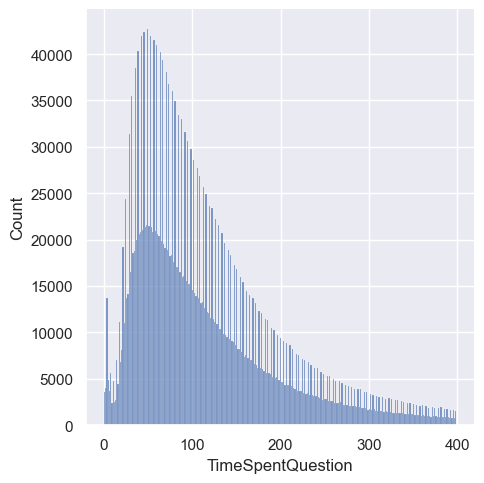

In [89]:
sns.displot(df_fca_no_outliers_question, x='TimeSpentQuestion')


#### Calculate the mean and median without outliers

In [90]:
meanqno = df_fca_no_outliers_question["TimeSpentQuestion"].mean()
medqno = df_fca_no_outliers_question["TimeSpentQuestion"].median()

print(f"The average of the time spent per question without outliers is {meanqno}")
print(f"The median of the time spent per question without outliers is {medqno}")

The average of the time spent per question without outliers is 114.53068768635006
The median of the time spent per question without outliers is 93.0


By removing the outliers, the average and the median got lower.

### Time spent test

#### Find the outliers

In [91]:
print(df_fca["TimeSpentTest"].value_counts())

TimeSpentTest
3600     29974
1697      3561
1651      3457
1681      3452
1683      3441
1660      3430
1699      3354
1677      3276
1659      3268
1685      3258
1658      3239
1706      3237
1688      3214
1696      3212
1700      3143
1694      3123
1680      3108
1690      3091
1691      3089
1645      3062
1689      3062
1714      3039
1647      3038
1676      3019
1687      3013
1610      3012
1693      3008
1701      2994
1704      2983
1698      2959
1692      2956
1640      2948
1674      2927
1663      2912
1679      2903
1648      2898
1666      2888
1695      2882
1627      2862
1642      2841
1707      2839
1656      2827
1623      2814
1631      2813
1650      2813
1686      2810
1634      2807
1678      2805
1624      2804
1667      2801
1657      2795
1655      2785
1668      2781
1618      2777
1625      2772
1671      2766
1626      2763
1643      2760
1665      2753
1684      2750
1715      2742
1609      2729
1653      2719
1637      2716
1619      2702
1673      2

In [92]:
print(f"Amount of different values for TimeSpentTest: {len(df_fca["TimeSpentTest"].unique())}")
print(f"Highest value TimeSpentTest: {df_fca["TimeSpentTest"].max()}")

Amount of different values for TimeSpentTest: 4403
Highest value TimeSpentTest: 86374


In [93]:
bins = list(range(0,86401, 100))

df_fca["TimeSpentTestInterval"] = pd.cut(df_fca["TimeSpentTest"], bins=bins, right=False)
df_fca.head()

,FCATestKey,FCAQuestionKey,ItemID,TimeSpentTest,TimeSpentQuestion,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification,TestStartTime,TestFinishTime,TimeSpentQuestionInterval,TimeSpentTestInterval
0,1,1,222,18,11,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)","[0, 100)"
1,1,2,223,18,3,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)","[0, 100)"
2,1,3,226,18,13,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)","[0, 100)"
3,1,4,229,18,100,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[100, 200)","[0, 100)"
4,1,5,238,18,2,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)","[0, 100)"


In [94]:
print(df_fca["TimeSpentTestInterval"].value_counts())

TimeSpentTestInterval
[1600, 1700)      278520
[1500, 1600)      192387
[1700, 1800)      175723
[3400, 3500)      158983
[3300, 3400)      150818
[3200, 3300)      127763
[1400, 1500)      125732
[3100, 3200)      111848
[2800, 2900)      104571
[3000, 3100)      104554
[2900, 3000)      102450
[2600, 2700)       98708
[2500, 2600)       97542
[2700, 2800)       96881
[2400, 2500)       93503
[2300, 2400)       92454
[2200, 2300)       91555
[2100, 2200)       90001
[1300, 1400)       87405
[2000, 2100)       86520
[1900, 2000)       86494
[1800, 1900)       82231
[3500, 3600)       74917
[1200, 1300)       65140
[1100, 1200)       48421
[3600, 3700)       39173
[1000, 1100)       38715
[900, 1000)        28779
[800, 900)         21277
[700, 800)         14716
[0, 100)           12973
[600, 700)         10254
[500, 600)          7160
[100, 200)          6562
[400, 500)          4783
[200, 300)          4159
[300, 400)          3571
[3700, 3800)        1930
[3800, 3900)        1158
[39

Seeing the counts, I'm choosing to only use the rows that have a TimeSpentTest between 700 and 3700

In [95]:
df_fca_no_outliers_test = df_fca[(df_fca["TimeSpentTest"] >= 700) & (df_fca["TimeSpentTest"] < 3700)]
df_fca_no_outliers_test.head()

,FCATestKey,FCAQuestionKey,ItemID,TimeSpentTest,TimeSpentQuestion,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification,TestStartTime,TestFinishTime,TimeSpentQuestionInterval,TimeSpentTestInterval
5,2,6,407,1993,111,854,Gender_Female,Gender_Female,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown,13:45:16,14:18:29,"[100, 200)","[1900, 2000)"
6,2,7,408,1993,286,854,Gender_Female,Gender_Female,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown,13:45:16,14:18:29,"[200, 300)","[1900, 2000)"
7,2,8,409,1993,413,854,Gender_Female,Gender_Female,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown,13:45:16,14:18:29,"[400, 500)","[1900, 2000)"
8,2,9,410,1993,167,854,Gender_Female,Gender_Female,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown,13:45:16,14:18:29,"[100, 200)","[1900, 2000)"
9,2,10,411,1993,609,854,Gender_Female,Gender_Female,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Qualification_Unknown,13:45:16,14:18:29,"[600, 700)","[1900, 2000)"


In [96]:
df_fca_outliers_test = df_fca[(df_fca["TimeSpentTest"] < 700) | (df_fca["TimeSpentTest"] >= 3700)]
df_fca_outliers_test.head()

,FCATestKey,FCAQuestionKey,ItemID,TimeSpentTest,TimeSpentQuestion,CandidateKey,Gender,ChosenGender,ChosenLanguage,Qualification,TestStartTime,TestFinishTime,TimeSpentQuestionInterval,TimeSpentTestInterval
0,1,1,222,18,11,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)","[0, 100)"
1,1,2,223,18,3,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)","[0, 100)"
2,1,3,226,18,13,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)","[0, 100)"
3,1,4,229,18,100,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[100, 200)","[0, 100)"
4,1,5,238,18,2,544,Gender_Female,Gender_Female,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Qualification_Unknown,09:31:54,09:32:12,"[0, 100)","[0, 100)"


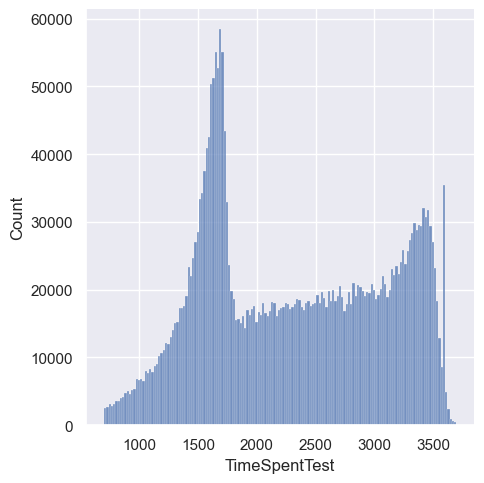

In [97]:
sns.displot(df_fca_no_outliers_test, x='TimeSpentTest')

In [98]:
meantno = df_fca_no_outliers_test["TimeSpentTest"].mean()
medtno = df_fca_no_outliers_test["TimeSpentTest"].median()

print(f"The average of the time spent per test without outliers is {meantno}")
print(f"The median of the time spent per test without outliers is {medtno}")

The average of the time spent per test without outliers is 2313.6586601235063
The median of the time spent per test without outliers is 2267.0


By removing the outliers the average got lower while the median got higher.

In [99]:
pd.reset_option('display.max_rows')

# Average values with filters (no outliers)

## Time spent question

### ItemID

In [100]:
mean_itemID_no = df_fca_no_outliers_question.groupby(["ItemID"])["TimeSpentQuestion"].mean()

med_itemID_no = df_fca_no_outliers_question.groupby(["ItemID"])["TimeSpentQuestion"].median()

df_avg_med_no = pd.concat([mean_itemID_no, med_itemID_no], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_avg_med_no.head()

,MeanTimeSpent,MedianTimeSpent
ItemID,,
117,274.440000,306.5
118,189.291667,177.0
119,183.706422,173.0
120,102.814159,87.0
121,147.675926,138.0


### Gender & ChosenGender

#### With outliers

In [101]:
mean_gender = df_fca.groupby(["Gender"])["TimeSpentQuestion"].mean()
med_gender = df_fca.groupby(["Gender"])["TimeSpentQuestion"].median()

df_filter_gender = pd.concat([mean_gender, med_gender], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_gender

,MeanTimeSpent,MedianTimeSpent
Gender,,
Gender_Female,182.763949,101.0
Gender_Male,178.950122,101.0
Gender_Unknown,170.860530,82.0


In [102]:
mean_gender_chosen = df_fca.groupby(["ChosenGender"])["TimeSpentQuestion"].mean()
med_gender_chosen = df_fca.groupby(["ChosenGender"])["TimeSpentQuestion"].median()

df_filter_gender_chosen = pd.concat([mean_gender_chosen, med_gender_chosen], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_gender_chosen

,MeanTimeSpent,MedianTimeSpent
ChosenGender,,
Gender_Female,182.777367,101.0
Gender_Male,178.940784,101.0
Gender_Other,175.029412,83.0
Gender_Unknown,175.557323,95.0


#### Without outliers

In [103]:
mean_gender = df_fca_no_outliers_question.groupby(["Gender"])["TimeSpentQuestion"].mean()
med_gender = df_fca_no_outliers_question.groupby(["Gender"])["TimeSpentQuestion"].median()

df_filter_gender = pd.concat([mean_gender, med_gender], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_gender

,MeanTimeSpent,MedianTimeSpent
Gender,,
Gender_Female,116.008313,94.0
Gender_Male,115.473463,94.0
Gender_Unknown,97.785688,78.0


In [104]:
mean_gender_chosen = df_fca_no_outliers_question.groupby(["ChosenGender"])["TimeSpentQuestion"].mean()
med_gender_chosen = df_fca_no_outliers_question.groupby(["ChosenGender"])["TimeSpentQuestion"].median()

df_filter_gender_chosen = pd.concat([mean_gender_chosen, med_gender_chosen], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_gender_chosen

,MeanTimeSpent,MedianTimeSpent
ChosenGender,,
Gender_Female,116.015309,94.0
Gender_Male,115.478572,94.0
Gender_Other,103.221707,73.5
Gender_Unknown,105.435176,90.0


### ChosenLanguage

#### With outliers

In [105]:
mean_language = df_fca.groupby(["ChosenLanguage"])["TimeSpentQuestion"].mean()
med_language = df_fca.groupby(["ChosenLanguage"])["TimeSpentQuestion"].median()

df_filter_language = pd.concat([mean_language, med_language], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_language

,MeanTimeSpent,MedianTimeSpent
ChosenLanguage,,
63B7DCBF-919E-49A6-8BF4-7CD9042C4C44,161.446280,109.0
65CAFEA9-CF49-43ED-99AA-83AFE0539978,197.494922,99.0
7B568B41-B1BF-4FFA-BD30-58164515B012,168.984959,110.0
8E412238-4764-44A8-A3D4-4881415D971D,159.238828,78.0
947295A7-E1B7-4D33-874C-91329EFA3679,197.003795,86.0
A80A08DB-5382-4025-B7B1-5AC73F2DA4CB,178.242879,83.0
BE3C46AE-0192-4A9B-ACEE-37E51836F77C,199.631769,108.0
C3389FD0-E729-4D22-8024-B8D6C76C380D,173.075758,94.0
D1E16E4B-9820-4203-A6AF-85A0538578CE,199.674059,89.0


#### Without outliers

In [106]:
mean_language = df_fca_no_outliers_question.groupby(["ChosenLanguage"])["TimeSpentQuestion"].mean()
med_language = df_fca_no_outliers_question.groupby(["ChosenLanguage"])["TimeSpentQuestion"].median()

df_filter_language = pd.concat([mean_language, med_language], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_language

,MeanTimeSpent,MedianTimeSpent
ChosenLanguage,,
63B7DCBF-919E-49A6-8BF4-7CD9042C4C44,120.746099,102.0
65CAFEA9-CF49-43ED-99AA-83AFE0539978,111.019097,93.0
7B568B41-B1BF-4FFA-BD30-58164515B012,122.549388,102.0
8E412238-4764-44A8-A3D4-4881415D971D,88.519478,73.0
947295A7-E1B7-4D33-874C-91329EFA3679,98.254032,83.0
A80A08DB-5382-4025-B7B1-5AC73F2DA4CB,88.975598,79.0
BE3C46AE-0192-4A9B-ACEE-37E51836F77C,120.619206,99.0
C3389FD0-E729-4D22-8024-B8D6C76C380D,112.503460,88.0
D1E16E4B-9820-4203-A6AF-85A0538578CE,106.700760,82.0


### Qualification

#### With outliers

In [107]:
mean_qual = df_fca.groupby(["Qualification"])["TimeSpentQuestion"].mean()
med_qual = df_fca.groupby(["Qualification"])["TimeSpentQuestion"].median()

df_filter_qual = pd.concat([mean_qual, med_qual], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_qual

,MeanTimeSpent,MedianTimeSpent
Qualification,,
,198.136364,87.0
Qualification_Bachelor,189.197235,102.0
Qualification_MBA,200.490618,119.0
Qualification_Master,205.824571,106.0
Qualification_PHD,217.863014,109.0
Qualification_PostGraduate,205.758653,111.0
Qualification_Professional,203.851892,100.0
Qualification_Secondary,177.203696,103.0
Qualification_Unknown,175.877096,99.0


#### Without outliers

In [108]:
mean_qual = df_fca_no_outliers_question.groupby(["Qualification"])["TimeSpentQuestion"].mean()
med_qual = df_fca_no_outliers_question.groupby(["Qualification"])["TimeSpentQuestion"].median()

df_filter_qual = pd.concat([mean_qual, med_qual], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_qual

,MeanTimeSpent,MedianTimeSpent
Qualification,,
,112.800000,68.5
Qualification_Bachelor,117.896617,94.0
Qualification_MBA,128.252937,110.0
Qualification_Master,120.541826,96.0
Qualification_PHD,122.788474,99.0
Qualification_PostGraduate,124.372677,100.0
Qualification_Professional,115.243026,91.0
Qualification_Secondary,117.073110,96.0
Qualification_Unknown,113.216914,92.0


## Time spent test

### Gender & ChosenGender

#### With outliers

In [109]:
mean_gender = df_fca.groupby(["Gender"])["TimeSpentTest"].mean()
med_gender = df_fca.groupby(["Gender"])["TimeSpentTest"].median()

df_filter_gender = pd.concat([mean_gender, med_gender], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_gender

,MeanTimeSpent,MedianTimeSpent
Gender,,
Gender_Female,2446.321729,2296.0
Gender_Male,2390.596591,2248.0
Gender_Unknown,2314.348939,1978.0


In [110]:
mean_gender_chosen = df_fca.groupby(["ChosenGender"])["TimeSpentTest"].mean()
med_gender_chosen = df_fca.groupby(["ChosenGender"])["TimeSpentTest"].median()

df_filter_gender_chosen = pd.concat([mean_gender_chosen, med_gender_chosen], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_gender_chosen

,MeanTimeSpent,MedianTimeSpent
ChosenGender,,
Gender_Female,2446.248622,2296.0
Gender_Male,2390.641014,2247.0
Gender_Other,2191.442907,2307.0
Gender_Unknown,2227.780500,2123.0


#### Without outliers

In [111]:
mean_gender = df_fca_no_outliers_test.groupby(["Gender"])["TimeSpentTest"].mean()
med_gender = df_fca_no_outliers_test.groupby(["Gender"])["TimeSpentTest"].median()

df_filter_gender = pd.concat([mean_gender, med_gender], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_gender

,MeanTimeSpent,MedianTimeSpent
Gender,,
Gender_Female,2333.621265,2301.0
Gender_Male,2313.440264,2267.0
Gender_Unknown,2162.354049,2061.0


In [112]:
mean_gender_chosen = df_fca_no_outliers_test.groupby(["ChosenGender"])["TimeSpentTest"].mean()
med_gender_chosen = df_fca_no_outliers_test.groupby(["ChosenGender"])["TimeSpentTest"].median()

df_filter_gender_chosen = pd.concat([mean_gender_chosen, med_gender_chosen], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_gender_chosen

,MeanTimeSpent,MedianTimeSpent
ChosenGender,,
Gender_Female,2333.546284,2301.0
Gender_Male,2313.426955,2266.0
Gender_Other,2267.471223,2307.0
Gender_Unknown,2227.655027,2135.5


### ChosenLanguage

#### With outliers

In [113]:
mean_language = df_fca.groupby(["ChosenLanguage"])["TimeSpentTest"].mean()
med_language = df_fca.groupby(["ChosenLanguage"])["TimeSpentTest"].median()

df_filter_language = pd.concat([mean_language, med_language], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_language

,MeanTimeSpent,MedianTimeSpent
ChosenLanguage,,
63B7DCBF-919E-49A6-8BF4-7CD9042C4C44,1946.954253,1668.0
65CAFEA9-CF49-43ED-99AA-83AFE0539978,2357.355460,2108.0
7B568B41-B1BF-4FFA-BD30-58164515B012,2119.504572,1714.0
8E412238-4764-44A8-A3D4-4881415D971D,1963.037772,1811.0
947295A7-E1B7-4D33-874C-91329EFA3679,1708.265655,1745.0
A80A08DB-5382-4025-B7B1-5AC73F2DA4CB,2354.031784,1842.0
BE3C46AE-0192-4A9B-ACEE-37E51836F77C,2506.471324,2359.0
C3389FD0-E729-4D22-8024-B8D6C76C380D,2655.276254,2672.0
D1E16E4B-9820-4203-A6AF-85A0538578CE,3128.703007,2540.0


#### Without outliers

In [114]:
mean_language = df_fca_no_outliers_test.groupby(["ChosenLanguage"])["TimeSpentTest"].mean()
med_language = df_fca_no_outliers_test.groupby(["ChosenLanguage"])["TimeSpentTest"].median()

df_filter_language = pd.concat([mean_language, med_language], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_language

,MeanTimeSpent,MedianTimeSpent
ChosenLanguage,,
63B7DCBF-919E-49A6-8BF4-7CD9042C4C44,1944.304996,1670.0
65CAFEA9-CF49-43ED-99AA-83AFE0539978,2242.696060,2127.0
7B568B41-B1BF-4FFA-BD30-58164515B012,2125.737121,1716.0
8E412238-4764-44A8-A3D4-4881415D971D,2095.650123,2018.0
947295A7-E1B7-4D33-874C-91329EFA3679,1763.674510,1745.0
A80A08DB-5382-4025-B7B1-5AC73F2DA4CB,1919.389726,1890.0
BE3C46AE-0192-4A9B-ACEE-37E51836F77C,2371.935118,2376.0
C3389FD0-E729-4D22-8024-B8D6C76C380D,2580.422286,2674.0
D1E16E4B-9820-4203-A6AF-85A0538578CE,2477.802531,2548.0


### Qualification

#### With outliers

In [115]:
mean_qual = df_fca.groupby(["Qualification"])["TimeSpentTest"].mean()
med_qual = df_fca.groupby(["Qualification"])["TimeSpentTest"].median()

df_filter_qual = pd.concat([mean_qual, med_qual], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_qual

,MeanTimeSpent,MedianTimeSpent
Qualification,,
,3062.000000,3062.0
Qualification_Bachelor,2651.815120,2490.0
Qualification_MBA,2881.291500,2936.0
Qualification_Master,2744.702941,2707.0
Qualification_PHD,2523.360929,2649.0
Qualification_PostGraduate,2650.205949,2718.0
Qualification_Professional,2511.359900,2539.0
Qualification_Secondary,2289.961568,1737.0
Qualification_Unknown,2347.005744,2148.0


#### Without outliers

In [116]:
mean_qual = df_fca_no_outliers_test.groupby(["Qualification"])["TimeSpentTest"].mean()
med_qual = df_fca_no_outliers_test.groupby(["Qualification"])["TimeSpentTest"].median()

df_filter_qual = pd.concat([mean_qual, med_qual], axis=1, keys=["MeanTimeSpent", "MedianTimeSpent"])
df_filter_qual

,MeanTimeSpent,MedianTimeSpent
Qualification,,
,3062.000000,3062.0
Qualification_Bachelor,2430.849279,2491.0
Qualification_MBA,2743.886612,2939.0
Qualification_Master,2609.858602,2706.0
Qualification_PHD,2502.998793,2649.0
Qualification_PostGraduate,2604.964636,2721.0
Qualification_Professional,2488.087581,2570.0
Qualification_Secondary,2111.404661,1743.0
Qualification_Unknown,2269.181565,2170.0
